<a href="https://colab.research.google.com/github/ferbeiro/calculo-numerico-2/blob/main/Calculo_Numerico_Atividade_I_Fernanda_Ribeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Cálculo Numérico — Atividade Prática I

**Prof. Raquel J. Lobosco**

- Fernanda Ribeiro   


# Parte A — Truncamento e arredondamento


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image

pd.set_option("display.precision", 10)

def truncar(x, n):
    fator = 10**n
    return math.trunc(x * fator) / fator

def erros(x_ref, x_aprox):
    ea = abs(x_ref - x_aprox)
    er = ea / abs(x_ref) if x_ref != 0 else np.nan
    ep = 100 * er
    return ea, er, ep

def vazao(r, L, mu, dp):
    return np.pi * r**4 * dp / (8 * mu * L)

def arredondar_inteiro_positivo(x):
    # Arredondamento convencional: 0,5 sobe.
    return np.floor(np.asarray(x) + 0.5).astype(int)


In [2]:

valores_A = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

linhas = []

for nome, x in valores_A.items():
    for n in range(5):
        aproximacoes = {
            "Truncamento": truncar(x, n),
            "Arredondamento": round(x, n)
        }

        for metodo, aprox in aproximacoes.items():
            ea, er, ep = erros(x, aprox)
            linhas.append({
                "Valor": nome,
                "Referência": x,
                "n": n,
                "Método": metodo,
                "Aproximação": aprox,
                "Erro absoluto": ea,
                "Erro relativo": er,
                "Erro percentual (%)": ep
            })

tabela_A = pd.DataFrame(linhas)
display(tabela_A)


,Valor,Referência,n,Método,Aproximação,Erro absoluto,Erro relativo,Erro percentual (%)
0,x1,3.14159265,0,Truncamento,3.0000,0.14159265,0.0450703404,4.5070340357
1,x1,3.14159265,0,Arredondamento,3.0000,0.14159265,0.0450703404,4.5070340357
2,x1,3.14159265,1,Truncamento,3.1000,0.04159265,0.0132393517,1.3239351703
3,x1,3.14159265,1,Arredondamento,3.1000,0.04159265,0.0132393517,1.3239351703
4,x1,3.14159265,2,Truncamento,3.1400,0.00159265,0.0005069562,0.0506956241
5,x1,3.14159265,2,Arredondamento,3.1400,0.00159265,0.0005069562,0.0506956241
6,x1,3.14159265,3,Truncamento,3.1410,0.00059265,0.0001886464,0.0188646354
7,x1,3.14159265,3,Arredondamento,3.1420,0.00040735,0.0001296635,0.0129663532
8,x1,3.14159265,4,Truncamento,3.1415,0.00009265,0.0000294914,0.0029491411
9,x1,3.14159265,4,Arredondamento,3.1416,0.00000735,0.0000023396,0.0002339578


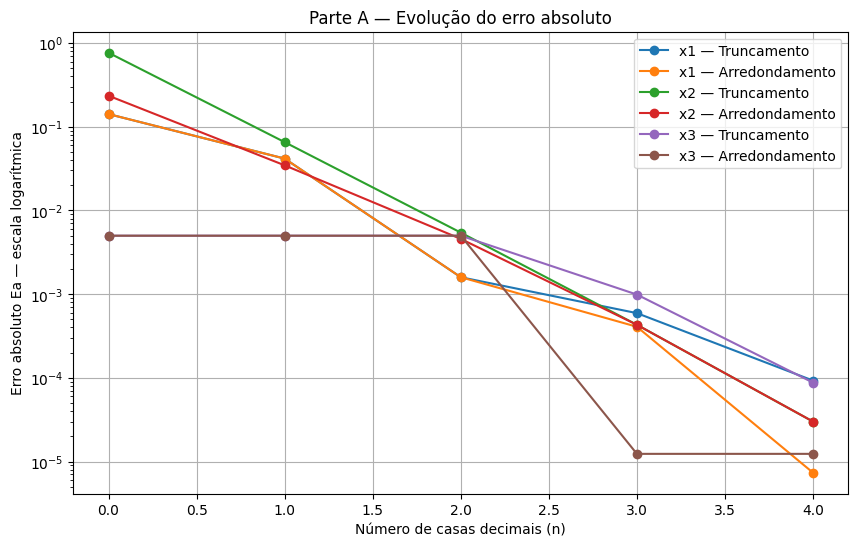

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))

for nome in valores_A:
    for metodo in ["Truncamento", "Arredondamento"]:
        dados = tabela_A[
            (tabela_A["Valor"] == nome) &
            (tabela_A["Método"] == metodo)
        ]
        ax.semilogy(
            dados["n"],
            dados["Erro absoluto"],
            marker="o",
            label=f"{nome} — {metodo}"
        )

ax.set_xlabel("Número de casas decimais (n)")
ax.set_ylabel("Erro absoluto Ea — escala logarítmica")
ax.set_title("Parte A — Evolução do erro absoluto")
ax.grid(True)
ax.legend()
plt.show()



### Resposta da Parte A

Para os valores e precisões, o arredondamento gera erro menor ou igual ao truncamento. Em alguns casos os dois produzem a mesma aproximação e, assim, o mesmo erro, como em:

- \(x_1=3,14159265\), com \(n=3\):
  - truncamento: \(3,141\), \(E_a=0,00059265\);
  - arredondamento: \(3,142\), \(E_a=0,00040735\).

- \(x_2=98,76543\), com \(n=0\):
  - truncamento: \(98\), \(E_a=0,76543\);
  - arredondamento: \(99\), \(E_a=0,23457\).

- \(x_3=0,00498765\), com \(n=3\):
  - truncamento: \(0,004\), \(E_a=0,00098765\);
  - arredondamento: \(0,005\), \(E_a=0,00001235\).

Isso porque o arredondamento escolhe o valor mais próximo na precisão adotada, enquanto o truncamento apenas elimina os algarismos posteriores.



# Parte B — Medidas de pressão arterial



In [4]:

pressao_original = np.array([
    121.7, 120.4, 122.1, 119.8, 121.2,
    120.9, 122.4, 121.0, 120.2, 121.5
])

pressao_arred = arredondar_inteiro_positivo(pressao_original)
pressao_trunc = np.trunc(pressao_original).astype(int)

series_B = {
    "Original": pressao_original,
    "Arredondada": pressao_arred,
    "Truncada": pressao_trunc
}

media_ref = np.mean(pressao_original)

def estatisticas(amostra):
    return {
        "Média (mmHg)": np.mean(amostra),
        "Mínimo (mmHg)": np.min(amostra),
        "Máximo (mmHg)": np.max(amostra),
        "Amplitude (mmHg)": np.max(amostra) - np.min(amostra),
        "Desvio-padrão amostral (mmHg)": np.std(amostra, ddof=1)
    }

tabela_estat_B = pd.DataFrame({
    nome: estatisticas(dados)
    for nome, dados in series_B.items()
}).T

display(tabela_estat_B)
print(f"Média de referência = {media_ref:.4f} mmHg")


,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio-padrão amostral (mmHg)
Original,121.12,119.8,122.4,2.6,0.8337332374
Arredondada,121.10,120.0,122.0,2.0,0.8755950358
Truncada,120.70,119.0,122.0,3.0,0.9486832981


Média de referência = 121.1200 mmHg


In [5]:

linhas_erros_B = []

for nome, dados in series_B.items():
    media = np.mean(dados)
    ea, er, ep = erros(media_ref, media)
    linhas_erros_B.append({
        "Série": nome,
        "Média (mmHg)": media,
        "Erro absoluto da média (mmHg)": ea,
        "Erro relativo da média": er,
        "Erro percentual da média (%)": ep
    })

tabela_erros_B = pd.DataFrame(linhas_erros_B)
display(tabela_erros_B)


,Série,Média (mmHg),Erro absoluto da média (mmHg),Erro relativo da média,Erro percentual da média (%)
0,Original,121.12,0.00,0.0000000000,0.0000000000
1,Arredondada,121.10,0.02,0.0001651255,0.0165125495
2,Truncada,120.70,0.42,0.0034676354,0.3467635403


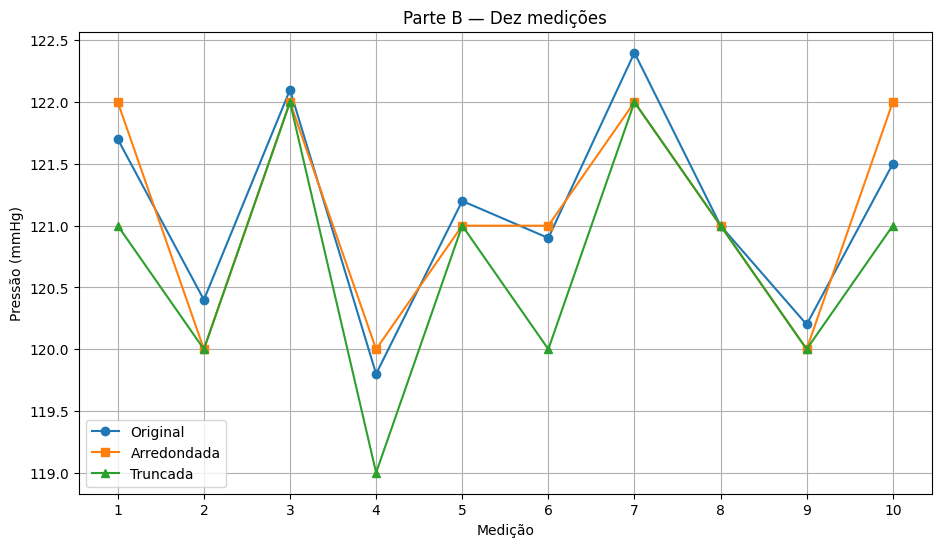

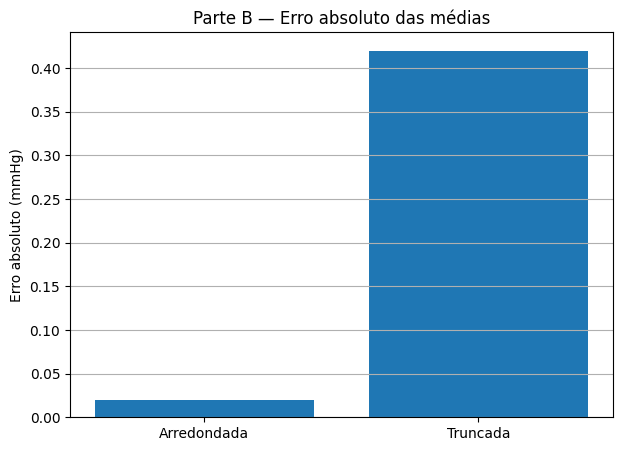

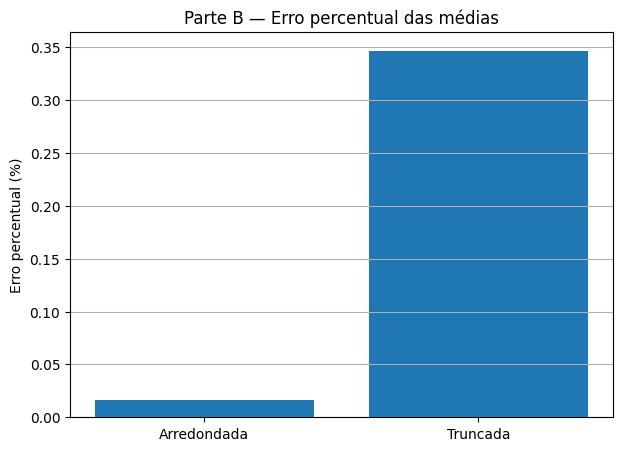

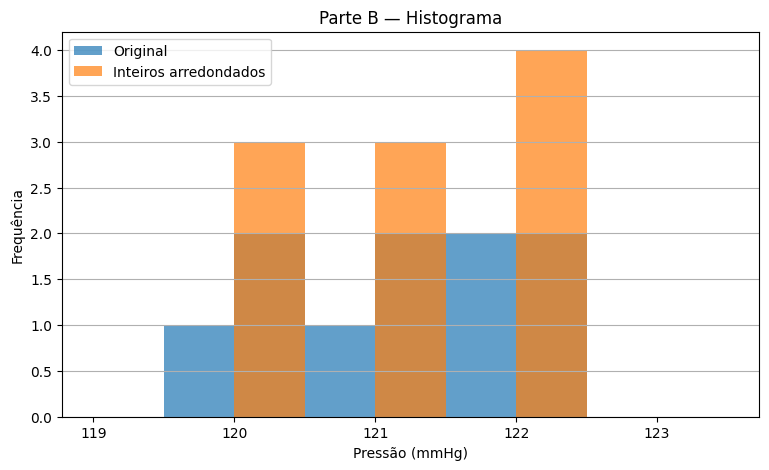

In [6]:

# O enunciado escreve "quatro séries", mas enumera somente três:
# original, arredondada e truncada. Aqui são usadas as três séries definidas.

medicao = np.arange(1, len(pressao_original) + 1)

plt.figure(figsize=(11, 6))
plt.plot(medicao, pressao_original, marker="o", label="Original")
plt.plot(medicao, pressao_arred, marker="s", label="Arredondada")
plt.plot(medicao, pressao_trunc, marker="^", label="Truncada")
plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")
plt.title("Parte B — Dez medições")
plt.xticks(medicao)
plt.grid(True)
plt.legend()
plt.show()

dados_aprox_B = tabela_erros_B[tabela_erros_B["Série"] != "Original"]

plt.figure(figsize=(7, 5))
plt.bar(
    dados_aprox_B["Série"],
    dados_aprox_B["Erro absoluto da média (mmHg)"]
)
plt.ylabel("Erro absoluto (mmHg)")
plt.title("Parte B — Erro absoluto das médias")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(
    dados_aprox_B["Série"],
    dados_aprox_B["Erro percentual da média (%)"]
)
plt.ylabel("Erro percentual (%)")
plt.title("Parte B — Erro percentual das médias")
plt.grid(axis="y")
plt.show()

bins = np.arange(119, 124, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(pressao_original, bins=bins, alpha=0.7, label="Original")
plt.hist(pressao_arred, bins=bins, alpha=0.7, label="Inteiros arredondados")
plt.xlabel("Pressão (mmHg)")
plt.ylabel("Frequência")
plt.title("Parte B — Histograma")
plt.legend()
plt.grid(axis="y")
plt.show()



### Análise da Parte B

A média original é **121,12 mmHg**. Após arredondamento para inteiros, ela passa para **121,10 mmHg**, com erro absoluto de **0,02 mmHg** e erro percentual de aproximadamente **0,0165%**. Após truncamento, a média é **120,70 mmHg**, com erro absoluto de **0,42 mmHg** e erro percentual de aproximadamente **0,3468%**.

O desvio-padrão amostral é aproximadamente:

- original: **0,8337 mmHg**;
- arredondado: **0,8756 mmHg**;
- truncado: **0,9487 mmHg**.

Assim, o arredondamento inteiro preserva bem a média, mas não preserva a variabilidade. O truncamento provoca uma alteração maior tanto na média quanto na dispersão.



# Parte C — Vazão em um tubo de pequeno diâmetro



In [7]:

r_mm = 0.80
r = r_mm * 1e-3
L = 0.20
mu = 3.5e-3
dp = 1200.0

Q_ref_C = vazao(r, L, mu, dp)

print(f"Q de referência = {Q_ref_C:.12e} m³/s")
print(f"Q de referência = {Q_ref_C*1e6:.12e} mL/s")


Q de referência = 2.757420751951e-07 m³/s
Q de referência = 2.757420751951e-01 mL/s


In [8]:

r_arred_mm = round(r_mm, 1)
r_trunc_mm = truncar(r_mm, 1)

mu_arred = round(mu, 3)
mu_trunc = truncar(mu, 3)

dp_arred = round(dp / 100) * 100
dp_trunc = math.trunc(dp / 100) * 100

cenarios_C = {
    "Referência": (r_mm, mu, dp),
    "r arred. 1 casa (mm)": (r_arred_mm, mu, dp),
    "r trunc. 1 casa (mm)": (r_trunc_mm, mu, dp),
    "mu arred. 3 casas": (r_mm, mu_arred, dp),
    "mu trunc. 3 casas": (r_mm, mu_trunc, dp),
    "dp arred. centenas": (r_mm, mu, dp_arred),
    "dp trunc. centenas": (r_mm, mu, dp_trunc),
    "Todas arredondadas": (r_arred_mm, mu_arred, dp_arred),
    "Todas truncadas": (r_trunc_mm, mu_trunc, dp_trunc)
}

linhas_C = []

for nome, (rmm_c, mu_c, dp_c) in cenarios_C.items():
    q = vazao(rmm_c * 1e-3, L, mu_c, dp_c)
    ea, er, ep = erros(Q_ref_C, q)
    linhas_C.append({
        "Cenário": nome,
        "r (mm)": rmm_c,
        "mu (Pa·s)": mu_c,
        "Δp (Pa)": dp_c,
        "Q (m³/s)": q,
        "Erro absoluto (m³/s)": ea,
        "Erro relativo": er,
        "Erro percentual (%)": ep
    })

tabela_C1 = pd.DataFrame(linhas_C)
display(tabela_C1)


,Cenário,r (mm),mu (Pa·s),Δp (Pa),Q (m³/s),Erro absoluto (m³/s),Erro relativo,Erro percentual (%)
0,Referência,0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
1,r arred. 1 casa (mm),0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
2,r trunc. 1 casa (mm),0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
3,mu arred. 3 casas,0.8,0.0040,1200.0,0.0000002413,0.0000000345,0.1250000000,12.5000000000
4,mu trunc. 3 casas,0.8,0.0030,1200.0,0.0000003217,0.0000000460,0.1666666667,16.6666666667
5,dp arred. centenas,0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
6,dp trunc. centenas,0.8,0.0035,1200.0,0.0000002757,0.0000000000,0.0000000000,0.0000000000
7,Todas arredondadas,0.8,0.0040,1200.0,0.0000002413,0.0000000345,0.1250000000,12.5000000000
8,Todas truncadas,0.8,0.0030,1200.0,0.0000003217,0.0000000460,0.1666666667,16.6666666667



### Análise de C.1

O raio \(0,80\) mm não muda quando arredondado ou truncado para uma casa decimal. Da mesma forma, \(1200\) Pa já é múltiplo de 100 Pa e permanece igual quando aproximado para centenas.

A viscosidade é o parâmetro que muda:

- arredondamento: \(0,0035\to0,004\) Pa·s;
- truncamento: \(0,0035\to0,003\) Pa·s.

A vazão de referência é aproximadamente

\[
Q=2,757420751951\times10^{-7}\ \text{m}^3/\text{s}.
\]

Como \(Q\propto1/\mu\), o arredondamento de \(\mu\) produz erro de aproximadamente 12,5% em \(Q\), enquanto o truncamento produz aproximadamente 16,67%.



## C.2 — Sensibilidade ao raio

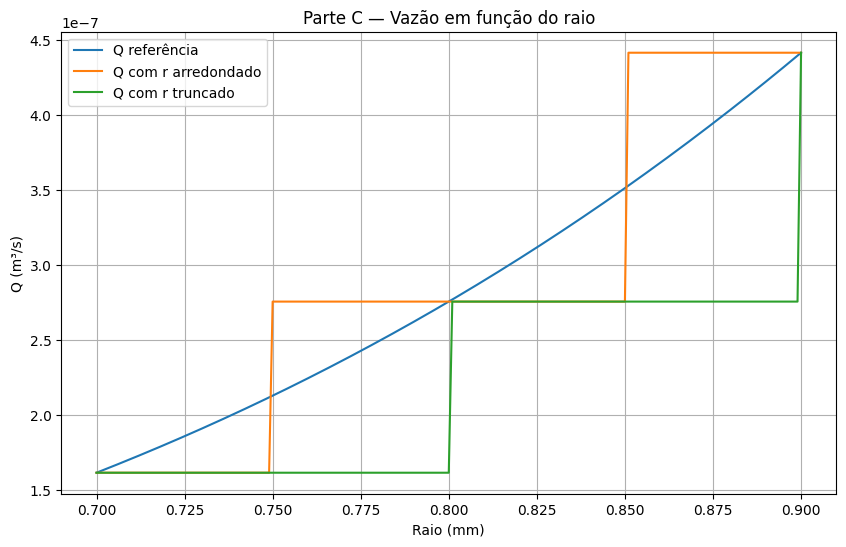

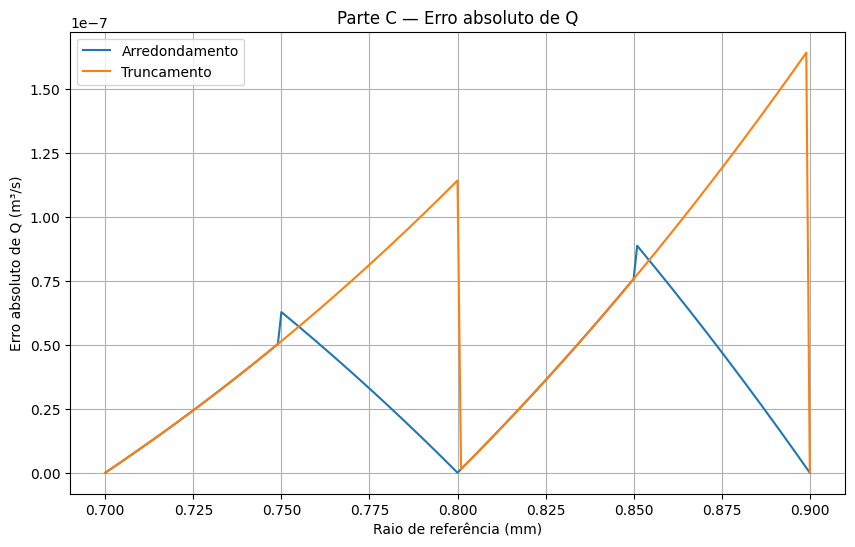

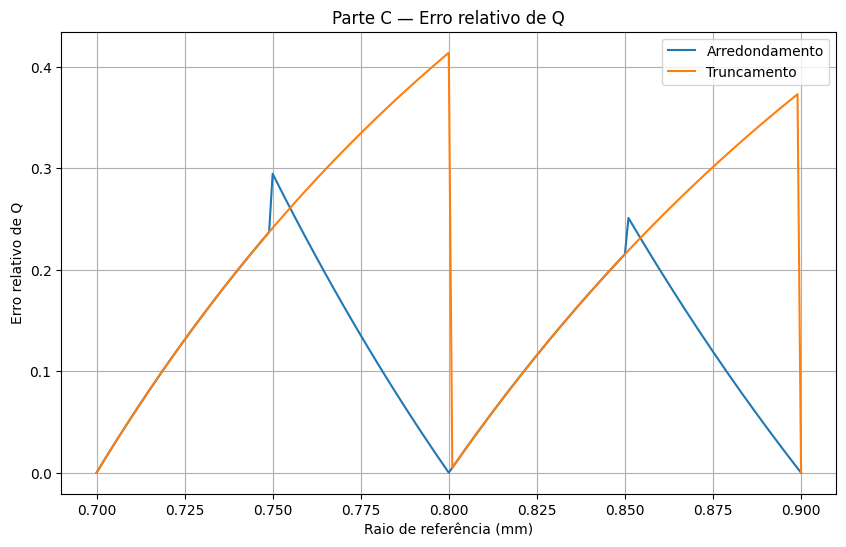

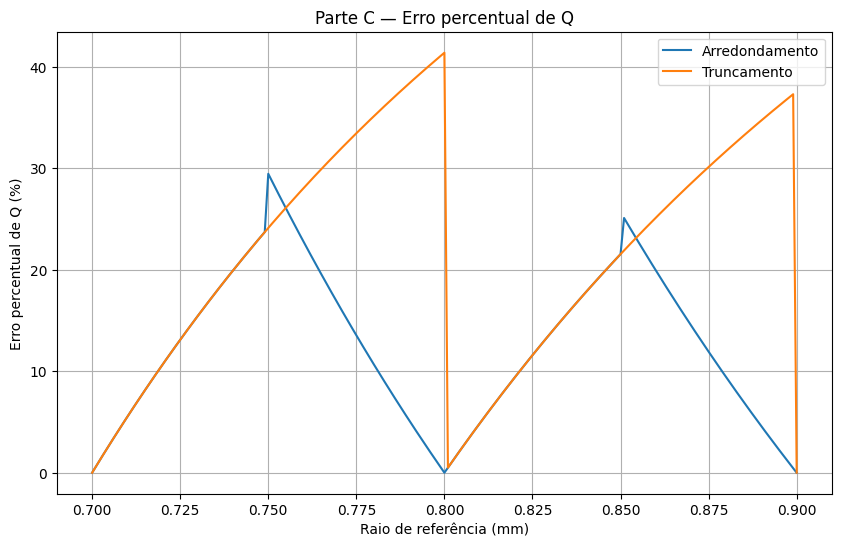

In [9]:

raios_mm = np.linspace(0.70, 0.90, 201)

Q_ref_sens = np.array([
    vazao(rr * 1e-3, L, mu, dp)
    for rr in raios_mm
])

raios_arred_mm = np.array([
    round(float(rr), 1)
    for rr in raios_mm
])

raios_trunc_mm = np.array([
    truncar(float(rr), 1)
    for rr in raios_mm
])

Q_arred_sens = np.array([
    vazao(rr * 1e-3, L, mu, dp)
    for rr in raios_arred_mm
])

Q_trunc_sens = np.array([
    vazao(rr * 1e-3, L, mu, dp)
    for rr in raios_trunc_mm
])

Ea_arred = np.abs(Q_ref_sens - Q_arred_sens)
Ea_trunc = np.abs(Q_ref_sens - Q_trunc_sens)

Er_arred = Ea_arred / np.abs(Q_ref_sens)
Er_trunc = Ea_trunc / np.abs(Q_ref_sens)

Ep_arred = 100 * Er_arred
Ep_trunc = 100 * Er_trunc

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Q_ref_sens, label="Q referência")
plt.plot(raios_mm, Q_arred_sens, label="Q com r arredondado")
plt.plot(raios_mm, Q_trunc_sens, label="Q com r truncado")
plt.xlabel("Raio (mm)")
plt.ylabel("Q (m³/s)")
plt.title("Parte C — Vazão em função do raio")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Ea_arred, label="Arredondamento")
plt.plot(raios_mm, Ea_trunc, label="Truncamento")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Erro absoluto de Q (m³/s)")
plt.title("Parte C — Erro absoluto de Q")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Er_arred, label="Arredondamento")
plt.plot(raios_mm, Er_trunc, label="Truncamento")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Erro relativo de Q")
plt.title("Parte C — Erro relativo de Q")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Ep_arred, label="Arredondamento")
plt.plot(raios_mm, Ep_trunc, label="Truncamento")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Erro percentual de Q (%)")
plt.title("Parte C — Erro percentual de Q")
plt.grid(True)
plt.legend()
plt.show()



### Explicação de C.2

Como

\[
Q\propto r^4,
\]

uma pequena variação do raio é amplificada na vazão. Se \(r\) passa para \(r(1+\varepsilon)\),

\[
\frac{Q_{\text{novo}}}{Q}=(1+\varepsilon)^4
=1+4\varepsilon+6\varepsilon^2+4\varepsilon^3+\varepsilon^4.
\]

Para \(|\varepsilon|\ll1\),

\[
\frac{\Delta Q}{Q}\approx4\frac{\Delta r}{r}.
\]

Logo, para perturbações pequenas, um erro relativo de cerca de 1% no raio pode produzir aproximadamente 4% de erro relativo na vazão.



# Parte D — Escoamento em um nanocateter



In [10]:

r0_nm = 50.0
r0 = r0_nm * 1e-9
L_D = 10e-6
mu_D = 3.5e-3
dp_D = 5000.0

Q0_D = vazao(r0, L_D, mu_D, dp_D)

print(f"Q(50 nm) = {Q0_D:.15e} m³/s")


Q(50 nm) = 3.506241800881466e-19 m³/s


## D.1 — Erro geométrico

In [11]:

delta_r_nm = np.arange(0.1, 5.0 + 0.05, 0.1)

r_menos_nm = r0_nm - delta_r_nm
r_mais_nm = r0_nm + delta_r_nm

Q_menos = np.array([
    vazao(rr * 1e-9, L_D, mu_D, dp_D)
    for rr in r_menos_nm
])

Q_mais = np.array([
    vazao(rr * 1e-9, L_D, mu_D, dp_D)
    for rr in r_mais_nm
])

erro_abs_max_D = np.maximum(
    np.abs(Q_menos - Q0_D),
    np.abs(Q_mais - Q0_D)
)

erro_rel_max_D = erro_abs_max_D / abs(Q0_D)
erro_pct_max_D = 100 * erro_rel_max_D

aprox_linear_rel = 4 * (delta_r_nm / r0_nm)
aprox_linear_pct = 100 * aprox_linear_rel

tabela_D1 = pd.DataFrame({
    "Δr (nm)": delta_r_nm,
    "r- (nm)": r_menos_nm,
    "r+ (nm)": r_mais_nm,
    "Q(r-) (m³/s)": Q_menos,
    "Q(r) (m³/s)": Q0_D,
    "Q(r+) (m³/s)": Q_mais,
    "Erro abs. máximo (m³/s)": erro_abs_max_D,
    "Erro rel. máximo": erro_rel_max_D,
    "Erro percentual máximo (%)": erro_pct_max_D,
    "Aprox. linear (%)": aprox_linear_pct
})

display(tabela_D1)


,Δr (nm),r- (nm),r+ (nm),Q(r-) (m³/s),Q(r) (m³/s),Q(r+) (m³/s),Erro abs. máximo (m³/s),Erro rel. máximo,Erro percentual máximo (%),Aprox. linear (%)
0,0.1,49.9,50.1,3.4782759041e-19,3.5062418009e-19,3.5343759973e-19,2.8134196466e-21,0.0080240320,0.8024032016,0.8
1,0.2,49.8,50.2,3.4504776346e-19,3.5062418009e-19,3.5626791674e-19,5.6437366522e-21,0.0160962563,1.6096256256,1.6
2,0.3,49.7,50.3,3.4228463210e-19,3.5062418009e-19,3.5911519863e-19,8.4910185387e-21,0.0242168653,2.4216865296,2.4
3,0.4,49.6,50.4,3.3953812937e-19,3.5062418009e-19,3.6197951305e-19,1.1355332962e-20,0.0323860521,3.2386052096,3.2
4,0.5,49.5,50.5,3.3680818840e-19,3.5062418009e-19,3.6486092780e-19,1.4236747715e-20,0.0406040100,4.0604010000,4.0
5,0.6,49.4,50.6,3.3409474249e-19,3.5062418009e-19,3.6775951081e-19,1.7135330721e-20,0.0488709327,4.8870932736,4.8
6,0.7,49.3,50.7,3.3139772506e-19,3.5062418009e-19,3.7067533013e-19,2.0051150041e-20,0.0571870144,5.7187014416,5.6
7,0.8,49.2,50.8,3.2871706966e-19,3.5062418009e-19,3.7360845396e-19,2.2984273871e-20,0.0655524495,6.5552449536,6.4
8,0.9,49.1,50.9,3.2605270997e-19,3.5062418009e-19,3.7655895063e-19,2.5934770540e-20,0.0739674330,7.3967432976,7.2
9,1.0,49.0,51.0,3.2340457984e-19,3.5062418009e-19,3.7952688860e-19,2.8902708513e-20,0.0824321600,8.2432160000,8.0


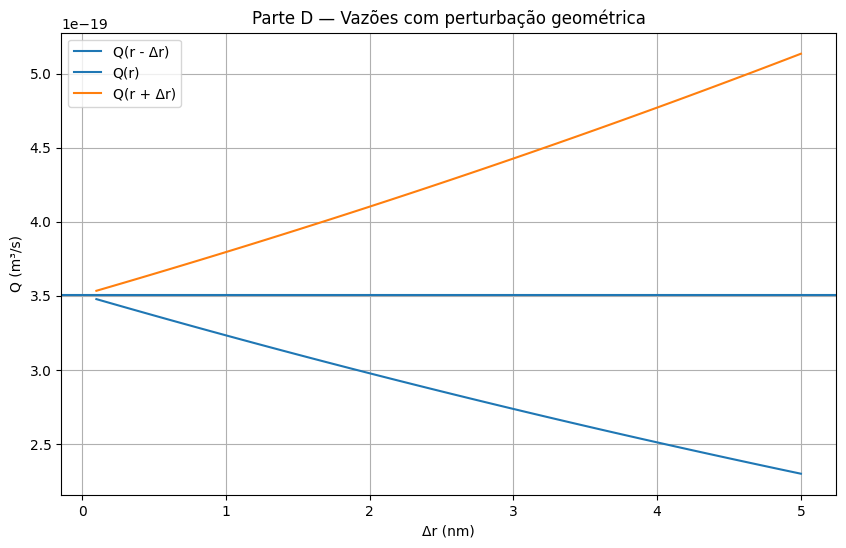

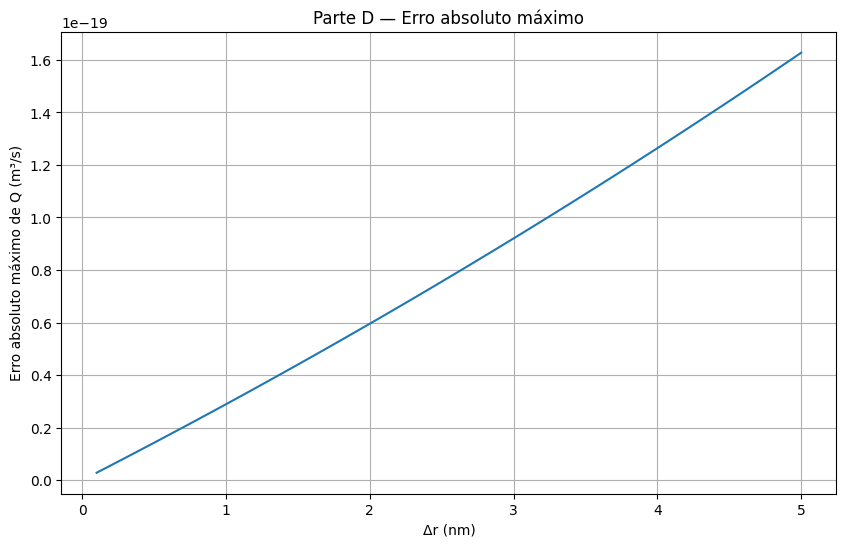

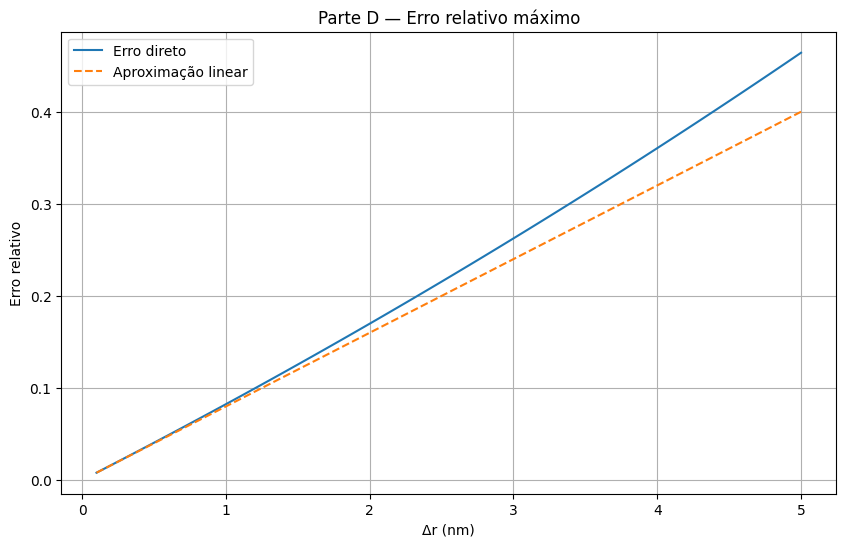

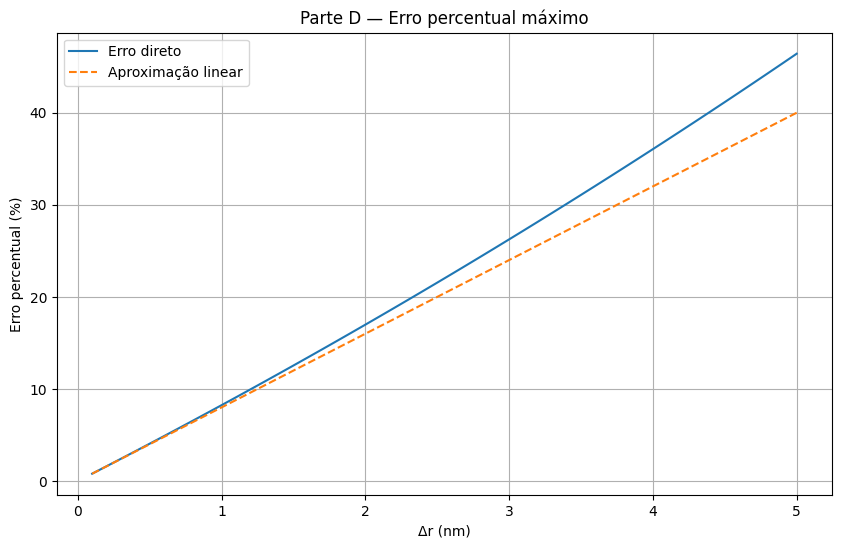

In [12]:

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, Q_menos, label="Q(r - Δr)")
plt.axhline(Q0_D, label="Q(r)")
plt.plot(delta_r_nm, Q_mais, label="Q(r + Δr)")
plt.xlabel("Δr (nm)")
plt.ylabel("Q (m³/s)")
plt.title("Parte D — Vazões com perturbação geométrica")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, erro_abs_max_D)
plt.xlabel("Δr (nm)")
plt.ylabel("Erro absoluto máximo de Q (m³/s)")
plt.title("Parte D — Erro absoluto máximo")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, erro_rel_max_D, label="Erro direto")
plt.plot(delta_r_nm, aprox_linear_rel, linestyle="--", label="Aproximação linear")
plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo")
plt.title("Parte D — Erro relativo máximo")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, erro_pct_max_D, label="Erro direto")
plt.plot(delta_r_nm, aprox_linear_pct, linestyle="--", label="Aproximação linear")
plt.xlabel("Δr (nm)")
plt.ylabel("Erro percentual (%)")
plt.title("Parte D — Erro percentual máximo")
plt.grid(True)
plt.legend()
plt.show()



### Comparação com a aproximação linear

A aproximação linear prevê aproximadamente **0,8%** de erro relativo em \(Q\). O cálculo direto do maior erro resulta em aproximadamente **0,8024%**, mostrando excelente concordância.

Para \(\Delta r=5\) nm, a razão é 10%. A aproximação linear prevê **40%**, enquanto o maior erro direto é aproximadamente **46,41%**. Nesse caso, os termos de ordem superior de \((1+\Delta r/r)^4\) já são importantes.


## D.2 — Precisão computacional

In [13]:

def vazao_dtype(r, L, mu, dp, dtype):
    pi = dtype(np.pi)
    r = dtype(r)
    L = dtype(L)
    mu = dtype(mu)
    dp = dtype(dp)
    return pi * r**dtype(4) * dp / (dtype(8) * mu * L)

r32 = np.float32(r0)
r64 = np.float64(r0)

r4_32 = np.float32(r32**np.float32(4))
r4_64 = np.float64(r64**np.float64(4))

Q32 = vazao_dtype(r0, L_D, mu_D, dp_D, np.float32)
Q64 = vazao_dtype(r0, L_D, mu_D, dp_D, np.float64)

dif_abs = abs(float(Q64) - float(Q32))
dif_rel = dif_abs / abs(float(Q64))

tabela_precisao = pd.DataFrame({
    "Tipo": ["float32", "float64"],
    "r^4 (m^4)": [r4_32, r4_64],
    "Q (m³/s)": [Q32, Q64],
    "eps": [np.finfo(np.float32).eps, np.finfo(np.float64).eps]
})

display(tabela_precisao)

print(f"Diferença absoluta em Q = {dif_abs:.15e} m³/s")
print(f"Diferença relativa em Q = {dif_rel:.15e}")
print(f"Diferença percentual = {100*dif_rel:.15e} %")


,Tipo,r^4 (m^4),Q (m³/s),eps
0,float32,6.2500003960e-30,3.5062423237e-19,1.1920928955e-07
1,float64,6.2500000000e-30,3.5062418009e-19,2.2204460493e-16


Diferença absoluta em Q = 5.228627674739853e-26 m³/s
Diferença relativa em Q = 1.491234196519299e-07
Diferença percentual = 1.491234196519299e-05 %



Valores esperados, aproximadamente:

- \(r^4\), `float32`: \(6,2500004\times10^{-30}\,\text{m}^4\);
- \(r^4\), `float64`: \(6,25\times10^{-30}\,\text{m}^4\);
- \(Q\), `float32`: \(3,5062423\times10^{-19}\,\text{m}^3/\text{s}\);
- \(Q\), `float64`: \(3,506241800881465\times10^{-19}\,\text{m}^3/\text{s}\);
- `eps(float32)` ≈ \(1,1920929\times10^{-7}\);
- `eps(float64)` ≈ \(2,2204460\times10^{-16}\).

A diferença relativa entre as vazões é da ordem de \(10^{-7}\), coerente com a menor precisão do `float32`.


,Tipo,Δr/r,δ1,δ2,|δ1-δ2|
0,float32,1.0000000000e-01,4.6410006285e-01,4.6410012245e-01,5.9604644775e-08
1,float32,1.0000000000e-02,4.0603745729e-02,4.0603995323e-02,2.4959445000e-07
2,float32,1.0000000000e-03,4.0060104802e-03,4.0061473846e-03,1.3690441847e-07
3,float32,1.0000000000e-04,3.9987856871e-04,4.0018558502e-04,3.0701630749e-07
4,float32,1.0000000000e-05,4.0105813241e-05,4.0054321289e-05,5.1491952036e-08
5,float32,1.0000000000e-06,3.9073679545e-06,3.8146972656e-06,9.2670688900e-08
6,float32,1.0000000000e-07,2.2117177423e-07,4.7683715820e-07,2.5566538397e-07
7,float32,1.0000000000e-08,0.0000000000e+00,0.0000000000e+00,0.0000000000e+00
8,float32,1.0000000000e-09,0.0000000000e+00,0.0000000000e+00,0.0000000000e+00
9,float32,1.0000000000e-10,0.0000000000e+00,0.0000000000e+00,0.0000000000e+00


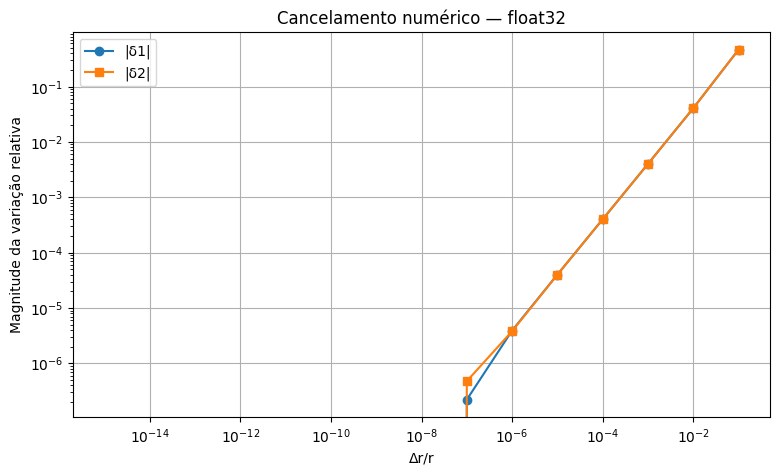

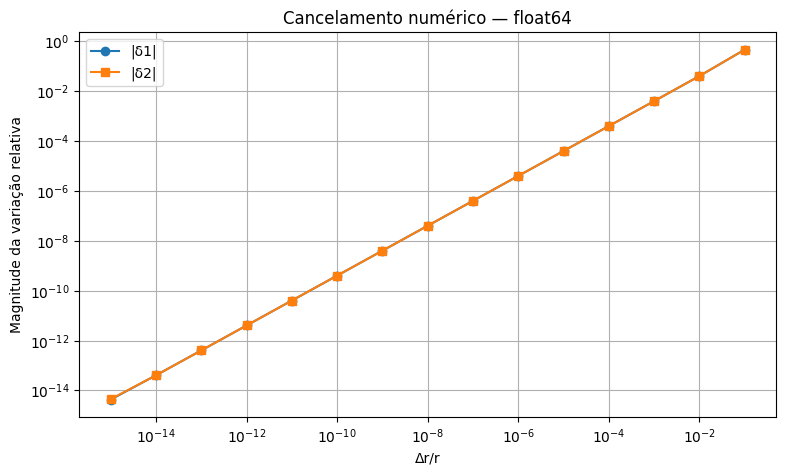

In [14]:

razoes = np.array([
    1e-1, 1e-2, 1e-3, 1e-4, 1e-5,
    1e-6, 1e-7, 1e-8, 1e-9, 1e-10,
    1e-11, 1e-12, 1e-13, 1e-14, 1e-15
])

def comparar_delta(dtype):
    resultados = []
    rr = dtype(r0)
    LL = dtype(L_D)
    mm = dtype(mu_D)
    pp = dtype(dp_D)
    Q_base = vazao_dtype(rr, LL, mm, pp, dtype)

    for razao in razoes:
        dr = dtype(rr * dtype(razao))
        Q_variado = vazao_dtype(rr + dr, LL, mm, pp, dtype)

        delta1 = dtype((Q_variado - Q_base) / Q_base)
        delta2 = dtype((dtype(1) + dr / rr)**dtype(4) - dtype(1))

        resultados.append({
            "Tipo": dtype.__name__,
            "Δr/r": razao,
            "δ1": float(delta1),
            "δ2": float(delta2),
            "|δ1-δ2|": abs(float(delta1) - float(delta2))
        })

    return resultados

tabela_cancelamento = pd.DataFrame(
    comparar_delta(np.float32) +
    comparar_delta(np.float64)
)

display(tabela_cancelamento)

for tipo in ["float32", "float64"]:
    dados = tabela_cancelamento[tabela_cancelamento["Tipo"] == tipo]

    plt.figure(figsize=(9, 5))
    plt.loglog(dados["Δr/r"], np.abs(dados["δ1"]), marker="o", label="|δ1|")
    plt.loglog(dados["Δr/r"], np.abs(dados["δ2"]), marker="s", label="|δ2|")
    plt.xlabel("Δr/r")
    plt.ylabel("Magnitude da variação relativa")
    plt.title(f"Cancelamento numérico — {tipo}")
    plt.grid(True)
    plt.legend()
    plt.show()



### Perda de significância por cancelamento

As expressões

\[
\delta_1=\frac{Q(r+\Delta r)-Q(r)}{Q(r)}
\]

e

\[
\delta_2=\left(1+\frac{\Delta r}{r}\right)^4-1
\]

são matematicamente equivalentes, mas podem perder precisão numérica para valores muito pequenos de \(\Delta r/r\).

Em \(\delta_1\), duas vazões quase iguais são subtraídas. Em \(\delta_2\), subtrai-se 1 de um número muito próximo de 1. Nos dois casos pode ocorrer cancelamento, isto é, perda dos algarismos significativos que representam a pequena diferença.

O problema aparece mais cedo em `float32`, pois sua precisão de máquina é da ordem de \(10^{-7}\). Para razões próximas de \(10^{-8}\), a pequena perturbação pode desaparecer na representação. Já `float64`, com precisão da ordem de \(10^{-16}\), consegue representar variações muito menores antes de sofrer o mesmo efeito.



## D.3 — Fenômeno físico

Quando a escala do canal é reduzida, a razão entre área superficial e volume aumenta. Com isso, uma parcela proporcionalmente maior do fluido fica próxima das paredes, tornando os efeitos viscosos, de atrito e de interação com a superfície mais importantes. Pequenas alterações geométricas também podem causar grandes variações na vazão, especialmente neste modelo em que \(Q\propto r^4\). Entretanto, um resultado com muitas casas decimais pode ser aritmeticamente muito preciso e ainda assim não representar perfeitamente o sistema físico real, caso o modelo idealizado deixe de considerar efeitos relevantes da nanoescala. Portanto, **precisão aritmética e validade física do modelo são conceitos diferentes**.



# Parte E — Síntese visual


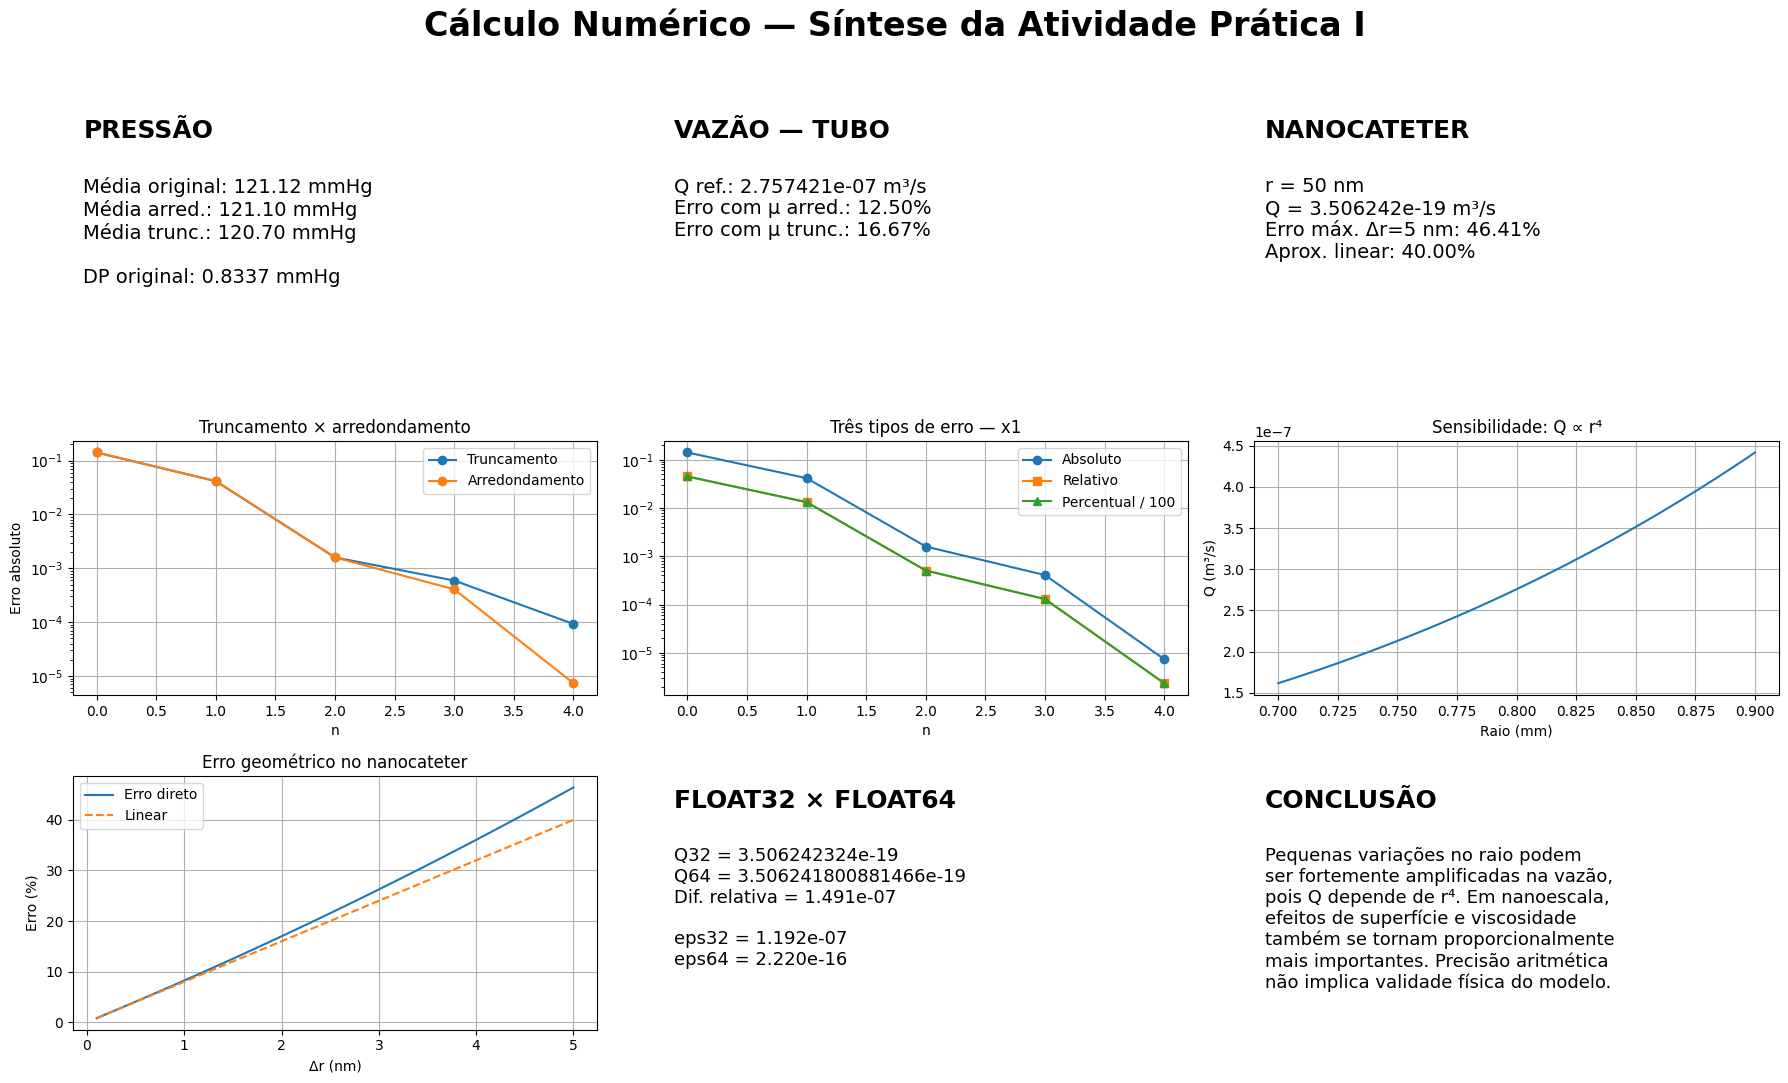

Arquivo criado: quadro_resultados_calculo_numerico.png


In [16]:

media_arred = np.mean(pressao_arred)
media_trunc = np.mean(pressao_trunc)

_, _, ep_mu_arred = erros(Q_ref_C, vazao(r, L, mu_arred, dp))
_, _, ep_mu_trunc = erros(Q_ref_C, vazao(r, L, mu_trunc, dp))

fig = plt.figure(figsize=(18, 11), dpi=100)
gs = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
ax1.text(0.02, 0.95, "PRESSÃO", fontsize=18, fontweight="bold", va="top")
ax1.text(
    0.02, 0.72,
    f"Média original: {media_ref:.2f} mmHg\n"
    f"Média arred.: {media_arred:.2f} mmHg\n"
    f"Média trunc.: {media_trunc:.2f} mmHg\n\n"
    f"DP original: {np.std(pressao_original, ddof=1):.4f} mmHg",
    fontsize=14, va="top"
)

ax2 = fig.add_subplot(gs[0, 1])
ax2.axis("off")
ax2.text(0.02, 0.95, "VAZÃO — TUBO", fontsize=18, fontweight="bold", va="top")
ax2.text(
    0.02, 0.72,
    f"Q ref.: {Q_ref_C:.6e} m³/s\n"
    f"Erro com μ arred.: {ep_mu_arred:.2f}%\n"
    f"Erro com μ trunc.: {ep_mu_trunc:.2f}%",
    fontsize=14, va="top"
)

ax3 = fig.add_subplot(gs[0, 2])
ax3.axis("off")
ax3.text(0.02, 0.95, "NANOCATETER", fontsize=18, fontweight="bold", va="top")
ax3.text(
    0.02, 0.72,
    f"r = 50 nm\n"
    f"Q = {Q0_D:.6e} m³/s\n"
    f"Erro máx. Δr=5 nm: {erro_pct_max_D[-1]:.2f}%\n"
    f"Aprox. linear: {aprox_linear_pct[-1]:.2f}%",
    fontsize=14, va="top"
)

ax4 = fig.add_subplot(gs[1, 0])
a_plot = tabela_A[tabela_A["Valor"] == "x1"]
for metodo in ["Truncamento", "Arredondamento"]:
    d = a_plot[a_plot["Método"] == metodo]
    ax4.semilogy(d["n"], d["Erro absoluto"], marker="o", label=metodo)
ax4.set_title("Truncamento × arredondamento")
ax4.set_xlabel("n")
ax4.set_ylabel("Erro absoluto")
ax4.grid(True)
ax4.legend()

ax5 = fig.add_subplot(gs[1, 1])
d = tabela_A[
    (tabela_A["Valor"] == "x1") &
    (tabela_A["Método"] == "Arredondamento")
]
ax5.plot(d["n"], d["Erro absoluto"], marker="o", label="Absoluto")
ax5.plot(d["n"], d["Erro relativo"], marker="s", label="Relativo")
ax5.plot(d["n"], d["Erro percentual (%)"]/100, marker="^", label="Percentual / 100")
ax5.set_yscale("log")
ax5.set_title("Três tipos de erro — x1")
ax5.set_xlabel("n")
ax5.grid(True)
ax5.legend()

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(raios_mm, Q_ref_sens)
ax6.set_title("Sensibilidade: Q ∝ r⁴")
ax6.set_xlabel("Raio (mm)")
ax6.set_ylabel("Q (m³/s)")
ax6.grid(True)

ax7 = fig.add_subplot(gs[2, 0])
ax7.plot(delta_r_nm, erro_pct_max_D, label="Erro direto")
ax7.plot(delta_r_nm, aprox_linear_pct, linestyle="--", label="Linear")
ax7.set_title("Erro geométrico no nanocateter")
ax7.set_xlabel("Δr (nm)")
ax7.set_ylabel("Erro (%)")
ax7.grid(True)
ax7.legend()

ax8 = fig.add_subplot(gs[2, 1])
ax8.axis("off")
ax8.text(0.02, 0.95, "FLOAT32 × FLOAT64", fontsize=18, fontweight="bold", va="top")
ax8.text(
    0.02, 0.72,
    f"Q32 = {float(Q32):.9e}\n"
    f"Q64 = {float(Q64):.15e}\n"
    f"Dif. relativa = {dif_rel:.3e}\n\n"
    f"eps32 = {np.finfo(np.float32).eps:.3e}\n"
    f"eps64 = {np.finfo(np.float64).eps:.3e}",
    fontsize=13, va="top"
)

ax9 = fig.add_subplot(gs[2, 2])
ax9.axis("off")
ax9.text(0.02, 0.95, "CONCLUSÃO", fontsize=18, fontweight="bold", va="top")
ax9.text(
    0.02, 0.72,
    "Pequenas variações no raio podem\n"
    "ser fortemente amplificadas na vazão,\n"
    "pois Q depende de r⁴. Em nanoescala,\n"
    "efeitos de superfície e viscosidade\n"
    "também se tornam proporcionalmente\n"
    "mais importantes. Precisão aritmética\n"
    "não implica validade física do modelo.",
    fontsize=13, va="top"
)

fig.suptitle(
    "Cálculo Numérico — Síntese da Atividade Prática I",
    fontsize=24, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

arquivo_png = "quadro_resultados_calculo_numerico.png"
plt.savefig(arquivo_png, dpi=100)
plt.show()

print("Arquivo criado:", arquivo_png)



# GIF demonstrativo


GIF criado: nanocateter_vazao.gif


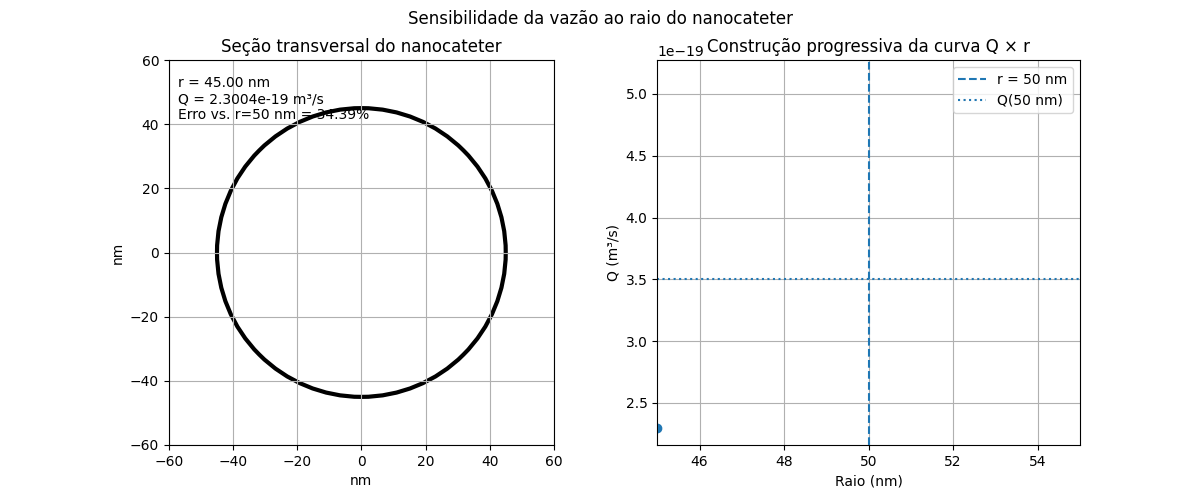

In [15]:

raios_gif_nm = np.linspace(45, 55, 40)
Q_gif = np.array([
    vazao(rr * 1e-9, L_D, mu_D, dp_D)
    for rr in raios_gif_nm
])

erro_pct_gif = 100 * np.abs(Q_gif - Q0_D) / abs(Q0_D)

fig, (ax_canal, ax_curva) = plt.subplots(1, 2, figsize=(12, 5))

def atualizar(frame):
    ax_canal.clear()
    ax_curva.clear()

    r_atual = raios_gif_nm[frame]
    q_atual = Q_gif[frame]
    erro_atual = erro_pct_gif[frame]

    circulo = plt.Circle((0, 0), r_atual, fill=False, linewidth=3)
    ax_canal.add_patch(circulo)
    ax_canal.set_xlim(-60, 60)
    ax_canal.set_ylim(-60, 60)
    ax_canal.set_aspect("equal")
    ax_canal.set_title("Seção transversal do nanocateter")
    ax_canal.set_xlabel("nm")
    ax_canal.set_ylabel("nm")
    ax_canal.grid(True)

    ax_canal.text(
        -57, 55,
        f"r = {r_atual:.2f} nm\n"
        f"Q = {q_atual:.4e} m³/s\n"
        f"Erro vs. r=50 nm = {erro_atual:.2f}%",
        va="top"
    )

    ax_curva.plot(
        raios_gif_nm[:frame+1],
        Q_gif[:frame+1],
        marker="o"
    )
    ax_curva.axvline(50, linestyle="--", label="r = 50 nm")
    ax_curva.axhline(Q0_D, linestyle=":", label="Q(50 nm)")
    ax_curva.set_xlim(45, 55)

    margem = 0.05 * (Q_gif.max() - Q_gif.min())
    ax_curva.set_ylim(Q_gif.min() - margem, Q_gif.max() + margem)
    ax_curva.set_xlabel("Raio (nm)")
    ax_curva.set_ylabel("Q (m³/s)")
    ax_curva.set_title("Construção progressiva da curva Q × r")
    ax_curva.grid(True)
    ax_curva.legend()

    fig.suptitle("Sensibilidade da vazão ao raio do nanocateter")

anim = FuncAnimation(
    fig,
    atualizar,
    frames=len(raios_gif_nm),
    interval=120,
    repeat=True
)

arquivo_gif = "nanocateter_vazao.gif"
anim.save(arquivo_gif, writer=PillowWriter(fps=8))
plt.close(fig)

print("GIF criado:", arquivo_gif)
display(Image(filename=arquivo_gif))



# Conclusão

A atividade mostrou que a representação numérica pode alterar os resultados de forma diferente em cada problema. Na Parte A, o arredondamento apresentou erro menor ou igual ao truncamento para os valores e precisões analisados. Nas medidas de pressão, o arredondamento para inteiros praticamente preservou a média, enquanto o truncamento introduziu erro maior e também modificou a variabilidade. Na equação de Hagen–Poiseuille, a dependência \(Q\propto r^4\) torna a vazão sensível ao raio, fazendo com que as variações geométricas sejam amplificadas. No nanocateter, essa sensibilidade é acompanhada pela maior importância relativa dos efeitos de superfície e viscosidade. A comparação entre `float32` e `float64` mostra que a precisão computacional limita a representação de diferenças muito pequenas e pode gerar perda de significância por cancelamento. Por fim, a alta precisão aritmética não garante validade física, ou seja, um cálculo pode ser numericamente preciso mesmo quando o modelo idealizado não descreve todos os efeitos do sistema real.
